---
tags: [tutorial]
---

# `qmc.control`と`qmc.select`によるcoherent制御

`qmc.control`を使うと、Qamomileの任意のゲート(`qmc.rx`のようなビルトイン関数や、ユーザが書いた`@qmc.qkernel`)の制御版を作れます。
このチュートリアルでは、まずそのAPIを詳しく説明し、最後に複数のunitary caseから1つをcoherentに選ぶ`qmc.select`を紹介します。

`qmc.control`には2つのモードがあります。*concrete mode*は制御量子ビットの数をPythonの`int`で与え、*symbolic mode*は`qmc.UInt`の量子カーネルパラメータ(あるいはそれを含む式)で与えてtranspile時に解決します。`power=`、デフォルト引数、`Vector[Qubit]`を取る量子カーネル、古典kwargの並び替えなど大半の機能は両モードで同じ挙動です。モードによって違うのは制御引数の渡し方と一部の追加機能だけで、以降のセクションで分けて扱います。

In [1]:
# Install the latest Qamomile from pip.
# !pip install qamomile

In [2]:
import math

import qamomile.circuit as qmc
from qamomile.circuit.transpiler.errors import UnreturnedBorrowError
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()

(cg-1)=
## 1. 最小例: controlled-RX

`qmc.control`の最も簡単かつ実用的な使い方は、Qamomileで用意されている1つのゲートを制御化することです。例えば以下では、1量子ビットゲートの`qmc.rx(q, angle)`を`qmc.control`に渡して、2量子ビットのcontrolled-RXゲートを得ています。

In [3]:
# 制御RXゲートを定義します。
crx = qmc.control(qmc.rx)

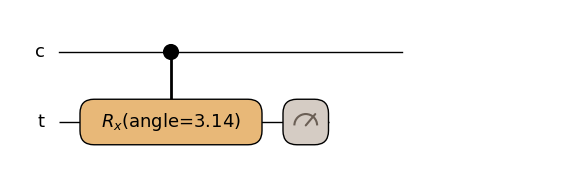

In [4]:
@qmc.qkernel
def crx_control_off() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    # 制御は|0>のままなので、制御回転は発火しません。
    c, t = crx(c, t, angle=math.pi)
    return qmc.measure(t)


crx_control_off.draw()

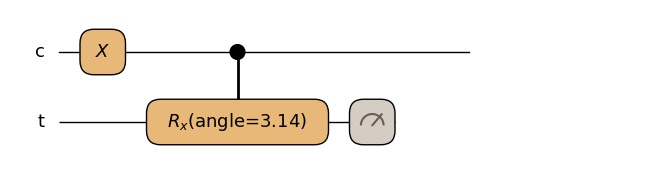

In [5]:
@qmc.qkernel
def crx_control_on() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    # 制御を|1>に立てるので、制御回転が発火します。
    c = qmc.x(c)
    c, t = crx(c, t, angle=math.pi)
    return qmc.measure(t)


crx_control_on.draw()

制御が実際に効いていることを確かめるために、両方の量子カーネルをQiskitにtranspileしてsimulatorで実行し、targetの測定結果を確認します。`angle=math.pi`では`RX(pi)`が|0>を|1>に写すので、制御が|1>のときだけtargetは全shotで|1>になり、それ以外では|0>のままになります。

In [6]:
off_counts = dict(
    transpiler.transpile(crx_control_off)
    .sample(transpiler.executor(), shots=256)
    .result()
    .results
)
on_counts = dict(
    transpiler.transpile(crx_control_on)
    .sample(transpiler.executor(), shots=256)
    .result()
    .results
)
print("control |0> ->", off_counts)
assert off_counts == {0: 256}
print("control |1> ->", on_counts)
assert on_counts == {1: 256}

control |0> -> {0: 256}
control |1> -> {1: 256}


ポイントとして、

- `crx = qmc.control(qmc.rx)`はqkernelの中でも外でもどちらに書いてもかまいません。返ってきたものは再利用可能な値なので、変数に置いて何度でも呼び出せます。
- `crx(c, t, angle=...)`を呼ぶと、まず制御量子ビットがpositional引数として並び、次にtarget、最後に古典keyword引数が続きます。順序は制御化する対象の`qmc.rx(q, angle)`シグネチャを踏襲しつつ、先頭に制御を加えた形です。
- 古典パラメータのkeyword名は制御化する対象の関数の名前をそのまま使います(`qmc.rx`なら`angle`、`qmc.p`なら`theta`など)。`qmc.control`が改名することはありません。

(cg-2)=
## 2. 2つのモードの概要

`qmc.control`には2つのモードがあります。どちらかは`num_controls`に渡す型だけで決まります。Pythonの`int`なら*concrete mode*、`qmc.UInt`ハンドル(あるいは`n - 1`のような`UInt`式)なら*symbolic mode*です。その他の挙動はすべてこの選択から決まります。

| 項目 | Concrete | Symbolic |
| --- | --- | --- |
| `num_controls=` | Pythonの`int`(デフォルト`1`) | `qmc.UInt`ハンドル、または`UInt`式 |
| 制御引数 | 合計量子ビット数が`num_controls`に一致する1つ以上のpositional引数(`Qubit`、`VectorView`、`Vector[Qubit]`) | 1つのpositionalな`Vector[Qubit]` / `VectorView`の*pool*(single-pool形、任意で`control_indices`)、**または**`Qubit` / `VectorView` / `Vector[Qubit]`を混ぜた複数のpositional引数 |
| `control_indices` | 受け付けない | 任意。poolのどの量子ビットがactiveかを指定 |
| `control_value` | 任意のPython `int`。LSB-firstでそのregister値のときにactive | 非対応。`num_controls`をbindしてconcrete modeを使う |
| 制御数が解決される時点 | `qmc.control(...)`が評価された時(module load時かtracing時) | transpile時(`bindings`から) |

`qmc.control`のほとんどの機能(`power=`、デフォルト値、古典kwargの並び替え、`Vector[Qubit]`を受け取る量子カーネル、multi-argの制御引数形など)は両モードで同じ挙動を示します。これらは[](#cg-3)でまとめます。[](#cg-4)はconcrete modeを必要とする機能を、[](#cg-5)はsymbolic mode固有の機能を扱います。

(cg-3)=
## 3. 両モードで動作するパターン

本セクションの各機能は、どちらのモードでも同じ挙動を示します。以下では原則concrete modeを使いますが、同じ機能がsymbolic modeでも利用可能です。concrete modeと違うのは`num_controls`が`UInt`式であることと、量子ビット数の一致がtranspile時にチェックされることだけです。symbolic専用の引数形は[](#cg-5)で扱います。

(cg-3-1)=
### 3.1 任意のcallableを制御化

`qmc.control`はビルトインのゲート関数(`qmc.rx`、`qmc.h`、`qmc.p`など)も、ユーザ定義の`@qmc.qkernel`も同様に受け付けます。以下の例では、`qmc.h`を制御化した`ch`とユーザ定義の`_h_then_rx`を制御化した`cg`の2つの制御演算を含む量子カーネルを扱います。

In [7]:
@qmc.qkernel
def _h_then_rx(q: qmc.Qubit, theta: qmc.Float) -> qmc.Qubit:
    q = qmc.h(q)
    q = qmc.rx(q, theta)
    return q


ch = qmc.control(qmc.h)
cg = qmc.control(_h_then_rx)

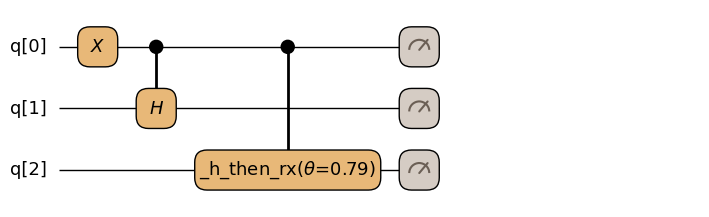

In [8]:
@qmc.qkernel
def control_any_callable_demo() -> qmc.Vector[qmc.Bit]:
    # q[0]は共通の制御。q[1] / q[2]は2つのtarget。
    q = qmc.qubit_array(3, "q")
    q[0] = qmc.x(q[0])
    q[0], q[1] = ch(q[0], q[1])
    q[0], q[2] = cg(q[0], q[2], theta=math.pi / 4)
    return qmc.measure(q)


control_any_callable_demo.draw()

(cg-3-2)=
### 3.2 `Vector[Qubit]`を受け取る量子カーネル

制御化する対象の量子カーネルは引数として`Vector[Qubit]`を取ることができます。呼び出し側は長さの一致する`Vector`または`VectorView`を渡します。

In [9]:
@qmc.qkernel
def _vec_h(qs: qmc.Vector[qmc.Qubit]) -> qmc.Vector[qmc.Qubit]:
    qs[0] = qmc.h(qs[0])
    qs[1] = qmc.h(qs[1])
    return qs


cg = qmc.control(_vec_h, num_controls=1)

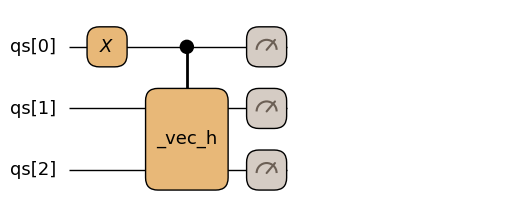

In [10]:
@qmc.qkernel
def vec_target_demo() -> qmc.Vector[qmc.Bit]:
    qs = qmc.qubit_array(3, "qs")
    qs[0] = qmc.x(qs[0])
    qs[0], qs[1:3] = cg(qs[0], qs[1:3])
    return qmc.measure(qs)


vec_target_demo.draw()

(cg-3-3)=
### 3.3 制御化する対象量子カーネルのシグネチャ由来のデフォルト値

制御化する対象の量子カーネルが古典パラメータにPythonのデフォルト値を宣言している場合、呼び出し側ではそのkeywordを省略することも可能です。

In [11]:
@qmc.qkernel
def _phase(
    q: qmc.Qubit,
    # runtime: ``_create_bound_input`` は ``qmc.Float`` 引数のデフォルトに
    # 生の ``float`` を受けて定数 ``Float`` handle に wrap する。静的シグネチャは
    # ハンドル型のままにしておくため、デフォルトリテラルが ``Float`` インスタンス
    # でないことを ``# type: ignore`` で許容する。
    theta: qmc.Float = math.pi / 2,  # type: ignore[assignment]
) -> qmc.Qubit:
    return qmc.rx(q, theta)


cg = qmc.control(_phase)

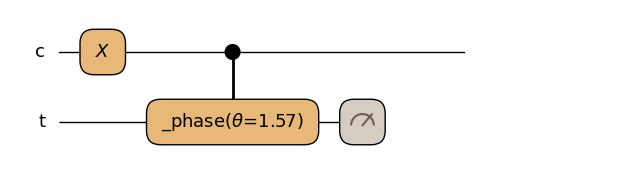

In [12]:
@qmc.qkernel
def default_arg_demo() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    c, t = cg(c, t)  # thetaはデフォルトのmath.pi / 2が入る
    return qmc.measure(t)


default_arg_demo.draw()

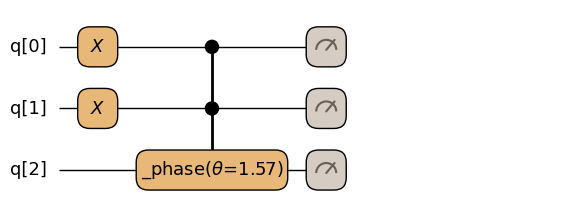

In [13]:
# 同じ`_phase`量子カーネルを、今度はsymbolicな`num_controls=n - 1`で制御化
# します。呼び出し側が`theta`を名指ししなくても`theta=math.pi / 2`の
# デフォルトはそのまま適用されます。別の角度を使いたいがkwargには
# 切り替えたくない場合は、省略した`theta`をcallsiteのpositional上書き
# (`cg(q[0 : n - 1], q[n - 1], math.pi / 4)`)に置き換えます。
@qmc.qkernel
def default_arg_demo_symbolic(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, "q")
    q[0 : n - 1] = qmc.x(q[0 : n - 1])  # 制御量子ビットを全て|1>にする
    cg = qmc.control(_phase, num_controls=n - 1)  # 制御量子ビット数をsymbolicに指定
    q[0 : n - 1], q[n - 1] = cg(q[0 : n - 1], q[n - 1])
    return qmc.measure(q)


default_arg_demo_symbolic.draw(n=3, fold_loops=False)

(cg-3-4)=
### 3.4 `power=`で`U^k`を制御

`power=k`を渡すと、`U`そのものではなく*k乗*の`U^k`が制御されます。`power`はPythonの`int`(コンパイル時に解決)も`qmc.UInt`ハンドル(`bindings`からtranspile時に解決)も受け取り、`num_controls`がconcreteかsymbolicかに関係なく動作します。

In [14]:
cg = qmc.control(qmc.rx)  # num_controls = 1 (concrete)

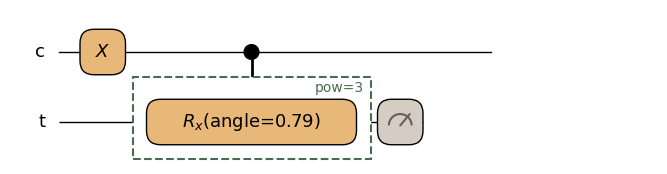

In [15]:
@qmc.qkernel
def power_demo_concrete() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)
    c, t = cg(c, t, angle=math.pi / 4, power=3)  # powerはPythonのint
    return qmc.measure(t)


power_demo_concrete.draw()

(cg-3-4-phase)=
#### global phaseは量子的な制御の下で観測可能になる

制御されていない演算全体に`exp(1j * phi)`を掛けても、通常の測定確率は
変わりません。それでもQamomileは、この位相を現在の回路領域（回路全体、`if`の
枝、`while`の本体など）の一部として保持します。ここで量子的な制御とは、制御
量子ビットを`|0>`と`|1>`の重ね合わせのまま使う制御です。可逆な領域をこの方法で
制御すると、位相はすべての制御量子ビットが`|1>`である成分だけに掛かる相対位相に
なります。identity Pauli項にも複素係数を持たせられるSELECT回路では、特に重要な
性質です。

Qamomileでは、次の関連する2通りで位相を付加できます。

- `qmc.global_phase(fn, phi)`は`fn`を通常どおり呼び出し、そのすべての戻り値を
  保ったまま、周囲の回路領域へ`exp(1j * phi)`を付加します。
- `qmc.control(fn)(..., global_phase=phi)`は、その制御呼び出しに
  位相を付加します。

通常の`qmc.global_phase`によるラッパーは`fn`に可逆性を要求しません。`fn`は
measure、reset、量子ビットの割り当て、古典値の返却を行ってもよく、量子演算を
まったく含まなくても構いません。可逆性は、これを含む量子カーネルを後から
`qmc.control`、`qmc.inverse`などで変換するときに初めて検査されます。
可逆演算`U`について、制御呼び出しの厳密な意味は
`control((exp(1j * phi) * U) ** power)`です。そのため`power=k`では位相も`k`回
反復され、inverseでは`U`の反転と一緒に位相の符号も反転します。
`global_phase`は呼び出し側の予約キーワードです。制御対象のcallableが同名の通常
パラメータを持つ場合は、そのパラメータを位置引数で渡してください。

測定結果など実行時に条件が決まる`if`の枝や`while`の本体で付加した位相は、
その枝または反復内にとどまります。回路全体へ移動したり破棄したりはしません。
選択した量子SDK/Engine/representationが要求された位相を正確に保持できない場合は、
変換中に明示的なエラーになります。

In [16]:
@qmc.qkernel
def _identity_for_phase(q: qmc.Qubit) -> qmc.Qubit:
    return q


controlled_phased_identity = qmc.control(_identity_for_phase)


@qmc.qkernel
def phase_kickback_demo() -> qmc.Bit:
    control = qmc.h(qmc.qubit("control"))
    target = qmc.qubit("target")
    control, target = controlled_phased_identity(
        control,
        target,
        global_phase=math.pi,
    )
    control = qmc.h(control)
    return qmc.measure(control)


phase_counts = dict(
    transpiler.transpile(phase_kickback_demo)
    .sample(transpiler.executor(), shots=256)
    .result()
    .results
)
assert phase_counts == {1: 256}

:::{note}
Qamomileは量子SDK/Engine/representationに依存しない1つの位相の意味を保ち、
各表現へ変換する前に、その表現が必要な位相と制御構造を扱えるか検証します。
Qiskitは回路全体または該当する制御構造の部分回路にある
`QuantumCircuit.global_phase`へ位相を保持します。Quration/PyQretはSDK組み込みの
`global_phase`演算、HUGRは
`tket_exts.global_phase()`を使います。CUDA-Qには回路全体のphase APIがないため、
既存の論理量子ビット上に厳密な恒等演算
`R1(2 phi) RZ(-2 phi)`を出力します。0量子ビットプログラムでは、Qamomileが
`|0>`で初期化された補助量子ビットを内部で1つ追加します。以下ではこれを位相用の
補助量子ビットと呼び、`RZ(-2 phi)`だけを適用して`exp(i phi)|0>`を厳密に
実現します。この補助量子ビットはmeasure結果や明示的な戻り値を持たない量子
カーネルの暗黙出力から除外されます。そのためCUDA-Qでも論理的な戻り値の構成を
変えずに位相を保持できます。
QURI Partsにも回路全体のphase APIがありません。数値として確定した位相と既存の
論理量子ビットがある場合は、その量子ビット上に厳密な恒等演算
`U1(2 phi) RZ(-2 phi)`を出力します。実行時パラメータを含む位相または0量子ビット
プログラムの位相では、同じ種類の位相用補助量子ビットへ`RZ(-2 phi)`を適用し、
`exp(i phi)|0>`を厳密に実現します。この補助量子ビットは、多重制御ゲートの合成に
使う別の補助量子ビットとは分離されています。

SDK自身が単独のglobal phaseを表現できても、再利用可能な量子カーネル全体へ
`control`や`inverse`を適用できるとは限りません。Quration/PyQretには一般的な
呼び出し変換APIがありません。`power`だけを指定した再利用可能呼び出しはnative
callのまま保たれ、指定回数だけ反復されます。`control`または`inverse`を適用する
場合は、Qamomileが対応範囲を限定して本体を展開します。`power`を併用すると、展開
した本体を指定回数だけ反復します。このfallbackは最大1個の量子制御、対応する基本
ゲート、1制御のPauli evolution、および定数範囲のstatic `For`（ネストを含む）を
扱います。HUGRも、対応する本体操作を同様に展開します。global phase自体は任意個の
制御量子ビットに対応し、3個以上の場合は、途中結果を保存する`|0>`の補助量子ビットと
Toffoliで全制御が1である条件を計算し、位相を付けた後に計算を逆順で戻して補助量子
ビットを解放します。実行時に範囲が決まる`For`、前の反復で計算した値を次の反復へ
渡す処理、実行時の`If` / `While`を含む変換対象の本体は、現在は明示的なエラーに
なります。
またHUGRの`power`は変換時に正の整数へ確定する必要があります。
対応範囲外の構造でも、位相だけを失って処理を続けることはありません。
:::

(cg-3-5)=
### 3.5 制御引数を別々のpositionalで渡す(CCXスタイル)

`num_controls=2`にすると、呼び出し側では各制御量子ビットをそれぞれ独立したpositional引数としてtargetの前に並べます。以下は典型的なCCX(Toffoli)で、2つの制御`c0`、`c1`と1つのtarget`t`を渡しています。同じパターンは`num_controls=3`(CCCX)や`num_controls=4`にも拡張でき、渡したい`Qubit`が`num_controls`で指定した数だけあれば成立します。

In [17]:
ccx = qmc.control(qmc.x, num_controls=2)

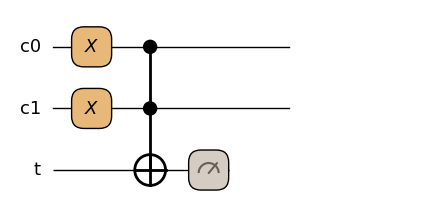

In [18]:
@qmc.qkernel
def toffoli_demo() -> qmc.Bit:
    c0 = qmc.qubit(name="c0")
    c1 = qmc.qubit(name="c1")
    t = qmc.qubit(name="t")
    c0 = qmc.x(c0)
    c1 = qmc.x(c1)
    c0, c1, t = ccx(c0, c1, t)
    return qmc.measure(t)


toffoli_demo.draw()

(cg-3-6)=
### 3.6 scalar Qubitと`VectorView`の制御を混ぜる

positional引数で渡す制御量子ビットは、合計量子ビット数が`num_controls`と一致する限り、scalarな`Qubit`、`VectorView`、`Vector[Qubit]`を自由に混ぜられます。以下では`num_controls=3`のcontrolled-Hに対し、3つの制御を`qs[0]`(scalar `Qubit`、1量子ビット)と`qs[1:3]`(`VectorView`、2量子ビット)で渡しています。

In [19]:
cg = qmc.control(qmc.h, num_controls=3)

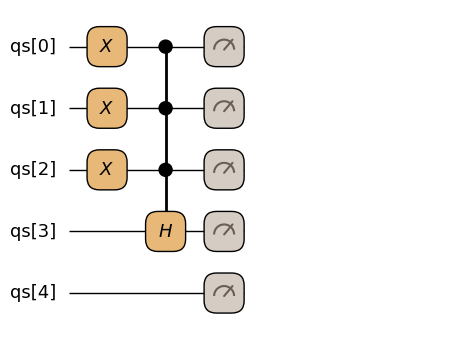

In [20]:
@qmc.qkernel
def mixed_controls_demo() -> qmc.Vector[qmc.Bit]:
    qs = qmc.qubit_array(5, "qs")
    qs[0] = qmc.x(qs[0])
    qs[1] = qmc.x(qs[1])
    qs[2] = qmc.x(qs[2])
    qs[0], qs[1:3], qs[3] = cg(qs[0], qs[1:3], qs[3])
    return qmc.measure(qs)


mixed_controls_demo.draw()

(cg-4)=
## 4. concrete mode専用のパターン

制御引数の形はほぼすべて両モードで動き([](#cg-3))、symbolic modeはさらに固有の機能を持ちます([](#cg-5))。concrete modeではこれに加え、単一scalar制御と、指定した計算基底値を条件にする制御を利用できます。

(cg-4-1)=
### 4.1 単一のscalar制御

単一のscalar `Qubit`を唯一の制御にする形はconcrete modeを必要とします。symbolic modeでは単一の制御引数はpoolの形と解釈され`Vector` / `VectorView`が要求されます。そもそも制御数が1に固定されている制御をsymbolicにする理由がないためです。これは[](#cg-1)の最小controlled-RXとまったく同じ形で、以下のcontrolled-X(CNOT)も同じ単一scalar制御の形です。

In [21]:
cx = qmc.control(qmc.x)  # num_controlsはデフォルトの1(concrete)

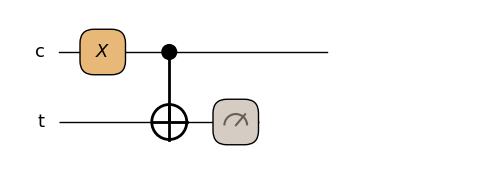

In [22]:
@qmc.qkernel
def cnot_demo() -> qmc.Bit:
    c = qmc.qubit(name="c")
    t = qmc.qubit(name="t")
    c = qmc.x(c)  # 制御を|1>に立ててXを発火させる
    c, t = cx(c, t)
    return qmc.measure(t)


cnot_demo.draw()

(cg-4-2)=
### 4.2 control registerの値を指定してactiveにする

通常の量子的な制御は、すべての制御量子ビットが`1`のときにactiveになります。
`control_value=v`を指定すると、代わりにflatten後のcontrol registerが具体的な整数
`v`を表すときにactiveになります。flattenは呼び出し順で行われ、各`Vector` /
`VectorView`はindex 0から昇順に要素を加えます。最初にflattenされた制御がbit 0
(LSB)です。そのため2制御で`control_value=2`なら
`(bit_0, bit_1) = (0, 1)`を意味します。

Qamomileはこれを1つの値指定付き制御演算として表現します。portable loweringは、
値が0の各制御bitについて制御の前後にXを適用することと等価で、これらの一時的な
Xは打ち消し合うため、返される制御量子ビットは保存されます。以下の例ではflatten順を
明確にするため、scalar制御と要素数1の`VectorView`を意図的に混在させます。

In [23]:
control_on_two = qmc.control(qmc.x, num_controls=2, control_value=2)
control_on_zero = qmc.control(qmc.x, num_controls=1, control_value=0)

In [24]:
@qmc.qkernel
def control_value_two_demo() -> qmc.Bit:
    qs = qmc.qubit_array(3, "qs")
    qs[1] = qmc.x(qs[1])  # flatten後の制御は(qs[0], qs[1]) = (0, 1)
    qs[0], qs[1:2], qs[2] = control_on_two(qs[0], qs[1:2], qs[2])
    return qmc.measure(qs[2])


@qmc.qkernel
def control_value_zero_demo() -> qmc.Bit:
    control = qmc.qubit("control")  # |0>のまま
    target = qmc.qubit("target")
    control, target = control_on_zero(control, target)
    return qmc.measure(target)

In [25]:
control_value_two_counts = dict(
    transpiler.transpile(control_value_two_demo)
    .sample(transpiler.executor(), shots=256)
    .result()
    .results
)
control_value_zero_counts = dict(
    transpiler.transpile(control_value_zero_demo)
    .sample(transpiler.executor(), shots=256)
    .result()
    .results
)
assert control_value_two_counts == {1: 256}
assert control_value_zero_counts == {1: 256}

`control_value=None`はデフォルトのall-ones制御です。all-onesを明示する
`2**num_controls - 1`を与えても、同じデフォルト表現へcanonicalizeされます。
その他の値は`0 <= control_value < 2**num_controls`を満たす必要があります。
`control_value`は意図的にconcrete mode専用です。`num_controls`が`qmc.UInt`の
場合は、まず幅をbindし、対応するconcreteな制御ゲートを構築してください。これに
より、演算を作る時点でactiveにするbit patternが一意に決まります。

(cg-5)=
## 5. Symbolic modeのパターン

本セクションは`num_controls`が`qmc.UInt`ハンドル(または`n - 1`のような`UInt`式)のときのパターン、symbolic modeについてみていきます。制御量子ビットの数は`qmc.control(..., num_controls=...)`の評価時ではなく、`bindings`からtranspile時に決まります。また、[](#cg-5-5)では[](#cg-3-5) / [](#cg-3-6)のsymbolic版を確認します。

制御量子ビットの渡し方としては以下の2種類があります。

- **Single-poolの形**([](#cg-5-1) – [](#cg-5-4)): 制御引数として`Vector[Qubit]`または`VectorView`を1つ渡し、pool全体、もしくは`control_indices`で選んだsubsetがactiveな制御として使用されます。
- **Multi-argの形**([](#cg-5-5)): 制御prefixが複数のpositional引数(scalar`Qubit`、`VectorView`、`Vector[Qubit]`、またはこれらの組み合わせ)で、量子ビット数の合計が`num_controls`と一致するよう渡します。concrete modeで見た([](#cg-3-5) / [](#cg-3-6))を、symbolicな`num_controls`に持ち上げたものです。

`control_indices`keywordはsymbolic mode専用で、single-poolの引数のどの量子ビットがactiveな制御として実際に配線されるかを指定します(残りはそのまま素通りします)。`control_indices`はsingle-poolの形でのみ有効で、multi-argの形と組み合わせるとrejectされます。

(cg-5-1)=
### 5.1 `num_controls = n`でpool全体を制御に

最もシンプルなsymbolicの形として`num_controls=n`としてpool(長さ`n`)全体を制御として使います。パラメータ`n`は`bindings`からtranspile時に具体化されます。

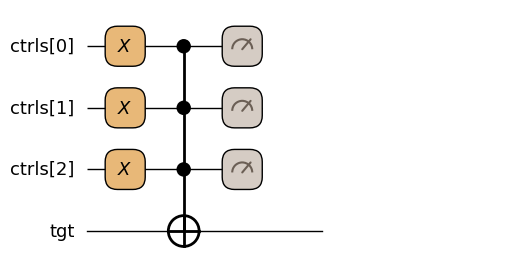

In [26]:
@qmc.qkernel
def symbolic_pool(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    ctrls = qmc.qubit_array(n, "ctrls")
    tgt = qmc.qubit(name="tgt")
    ctrls = qmc.x(ctrls)  # 制御を全て|1>にする
    cg = qmc.control(qmc.x, num_controls=n)  # シンボリックなnを制御数に指定
    ctrls, tgt = cg(ctrls, tgt)
    return qmc.measure(ctrls)


symbolic_pool.draw(n=3, fold_loops=False)

(cg-5-2)=
### 5.2 `n - 1`の典型的なmulti-controlled形

multi-controlled-X設計で頻出する形で、レジスタの最初の`n - 1`量子ビットを制御に、最後の1量子ビットをtargetにします。`num_controls`の値はsymbolic式の`n - 1`で、制御引数はスライス`qs[0:n - 1]`です。

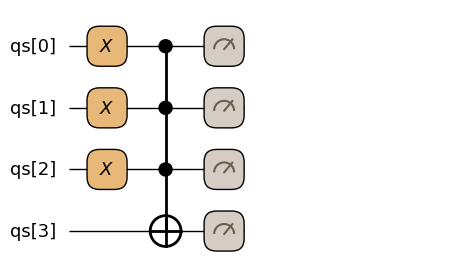

In [27]:
@qmc.qkernel
def mcx_demo(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    qs = qmc.qubit_array(n, "qs")
    qs[0 : n - 1] = qmc.x(qs[0 : n - 1])  # 制御部分を全て|1>にする
    mcx = qmc.control(qmc.x, num_controls=n - 1)
    qs[0 : n - 1], qs[n - 1] = mcx(qs[0 : n - 1], qs[n - 1])
    return qmc.measure(qs)


mcx_demo.draw(n=4, fold_loops=False)

(cg-5-3)=
### 5.3 `control_indices`でsubsetを選ぶ

制御poolがactiveな制御数より広い場合、`control_indices`keyword(symbolic mode専用)でpoolのどの量子ビットを制御として使うかを指定します。残りの量子ビットには触りません。indexは連続である必要はありません。

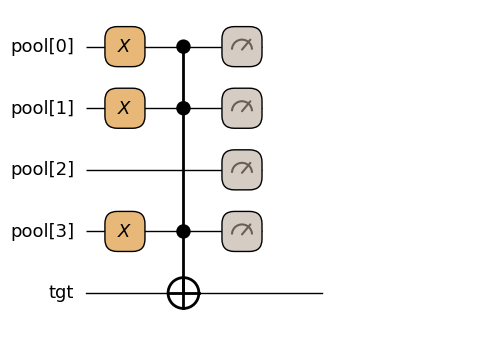

In [28]:
@qmc.qkernel
def subset_pool(n: qmc.UInt, k_ctrls: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    pool = qmc.qubit_array(n, "pool")
    tgt = qmc.qubit(name="tgt")
    pool[0] = qmc.x(pool[0])
    pool[1] = qmc.x(pool[1])
    pool[3] = qmc.x(pool[3])  # pool[2]は|0>のまま。これがinactiveな量子ビット。
    cg = qmc.control(qmc.x, num_controls=k_ctrls)
    pool, tgt = cg(pool, tgt, control_indices=[0, 1, 3])
    return qmc.measure(pool)


subset_pool.draw(n=4, k_ctrls=3)

(cg-5-4)=
### 5.4 `control_indices`に`UInt`式を含める

`control_indices`の各エントリはPythonの`int`リテラル、`qmc.UInt`でも`UInt`値による算術式のいずれでも構いません。リテラル`int`エントリに対する軽い構造チェック(`bool`、負値、リテラル`int`同士の重複の拒否)はcompose時に行われますが、それ以外、すなわち`num_controls`との長さ整合、pool sizeに対する範囲、`UInt`の値解決を必要とするチェックはtranspile時、`bindings`からパラメータが具体化されてからに先送りされます。

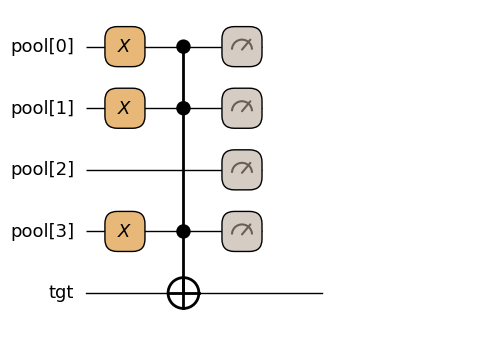

In [29]:
@qmc.qkernel
def subset_pool_with_uint(n: qmc.UInt, k_ctrls: qmc.UInt) -> qmc.Vector[qmc.Bit]:
    pool = qmc.qubit_array(n, "pool")
    tgt = qmc.qubit(name="tgt")
    pool[0] = qmc.x(pool[0])
    pool[1] = qmc.x(pool[1])
    pool[3] = qmc.x(pool[3])
    cg = qmc.control(qmc.x, num_controls=k_ctrls)
    pool, tgt = cg(pool, tgt, control_indices=[0, 1, n - 1])
    return qmc.measure(pool)


subset_pool_with_uint.draw(n=4, k_ctrls=3)

(cg-5-5)=
### 5.5 Multi-argの制御prefix

制御を複数のpositional引数に分けたい場合、(典型的には「同じ`Vector`のいくつかの量子ビットをactiveな制御に、別の量子ビットをtargetにしたい」場合)symbolic modeでもconcrete modeと同じmulti-argの形([](#cg-3-5) / [](#cg-3-6))が使えます。同じ`Vector[Qubit]`から複数の量子ビットを取り出しても、互いにdisjoint(重ならない)な量子ビットであれば制御prefixに並べられます。制御prefixの各引数の量子ビット数の合計が、transpile時に`num_controls`と照合されます。

なお、`control_indices`はmulti-argの形では使えません([](#cg-6)のreject caseを参照)。subset選択が必要ならsingle-poolの形([](#cg-5-3) / [](#cg-5-4))、multi-argの自由度が必要ならprefix全体をactiveとして使うかのどちらかを選んでください。

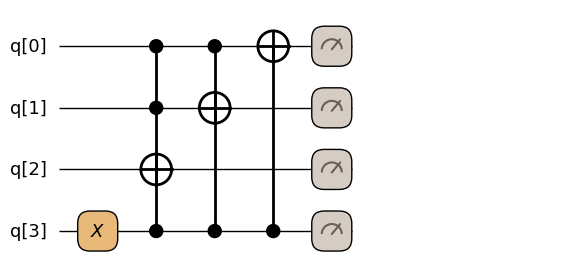

In [30]:
@qmc.qkernel
def controlled_increment_demo(
    n: qmc.UInt, control_index: qmc.UInt
) -> qmc.Vector[qmc.Bit]:
    q = qmc.qubit_array(n, "q")
    q[control_index] = qmc.x(q[control_index])
    # ``q.shape[0]`` は ``int | UInt`` 型なので、`n` パラメータ (狭い
    # ``qmc.UInt``) に再代入すると型が広がる。ローカル名で受ける。
    n_shape = q.shape[0]
    for k in qmc.range(n_shape - 1):
        target_idx = n - 2 - k
        ctrl_main = q[control_index]
        prefix = q[0:target_idx]
        tgt = q[target_idx]
        cg = qmc.control(qmc.x, num_controls=target_idx + 1)
        ctrl_main, prefix, tgt = cg(ctrl_main, prefix, tgt)
        q[control_index] = ctrl_main
        q[0:target_idx] = prefix
        q[target_idx] = tgt
    return qmc.measure(q)


controlled_increment_demo.draw(n=4, control_index=3, fold_loops=False)

(cg-6)=
## 6. rejectされるパターンとedge case

本章ではrejectされる呼び出し形を1つずつ見ていきます。最後に、nested blockをgateへ変換できるbackend(Qiskitなど)でsupportedな、sliced-QFTのconcrete caseもregression例として確認します。

| ケース | モード | 例外 |
| --- | --- | --- |
| 6.1 制御量子ビット数が引数境界をまたぐ | concrete | `ValueError` |
| 6.2 concrete modeで`control_indices` | concrete | `ValueError` |
| 6.3 concrete modeでsymbolic長の`VectorView` | concrete | `ValueError` |
| 6.4 同じpool量子ビットをtargetに再利用 | symbolic | `UnreturnedBorrowError` |
| 6.5 multi-arg制御prefix + `control_indices` | symbolic | `ValueError` |
| 6.6 symbolic modeで単一scalar制御 | symbolic | `ValueError` |
| 6.7 sub-kernel内の`UInt` sliceに対するcontrolled QFT | concrete | block-to-gate変換が成功する場合はsupported |

In [31]:
def expect_error(label: str, exc_type: type[BaseException], body) -> None:
    """``body``が``exc_type``の例外を投げることをassertします。

    ヘルパは*想定*の例外クラスだけをcatchします。それ以外の
    例外はそのまま伝播するので、別の例外型に変わってしまうような
    regressionはnotebook上で通常のtracebackとして見えます。
    例外が一度も発生しなかった場合は``AssertionError``を投げます。
    """
    try:
        body()
    except exc_type as exc:
        print(f"[{type(exc).__name__}] {label}: {exc}")
        return
    raise AssertionError(
        f"{label}: expected {exc_type.__name__}, but no exception was raised"
    )

(cg-6-1)=
### 6.1 制御量子ビット数が引数境界をまたぐ (concrete)

concrete modeはpositional引数を順に確認して、各引数を制御リストに畳み込むということを累計が`num_controls`に達するまで続けます。`VectorView`や`Vector`が与えられ、そこまでの累計の量子ビット数が`num_controls`を超えるような場合にはエラーが起きます。

In [32]:
def case_count_mismatch() -> None:
    @qmc.qkernel
    def kernel() -> qmc.Bit:
        qs = qmc.qubit_array(6, "qs")
        cg = qmc.control(qmc.x, num_controls=3)
        view, t = cg(qs[0:5], qs[5])  # 5量子ビット渡しているが3expected
        qs[0:5] = view
        return qmc.measure(qs[5])

    _ = kernel.block


expect_error("control count mismatch", ValueError, case_count_mismatch)

[ValueError] control count mismatch: concrete num_controls=3: positional argument #0 would push the control qubit count from 0 to 5, crossing the control / sub-kernel boundary mid-argument.  Split the argument so the boundary falls between args.


(cg-6-2)=
### 6.2 concrete modeで`control_indices` (concrete)

`control_indices`は選択元となる制御*pool*がある時にだけ意味を持つsymbolic modeの専用の引数です。concreteな`num_controls`と一緒に渡すと、compose時に`ValueError`になります。

In [33]:
def case_control_indices_in_concrete() -> None:
    @qmc.qkernel
    def kernel() -> qmc.Bit:
        c = qmc.qubit(name="c")
        t = qmc.qubit(name="t")
        cg = qmc.control(qmc.x)  # num_controlsはデフォルトの1 (concrete)
        c, t = cg(c, t, control_indices=[0])
        return qmc.measure(t)

    _ = kernel.block


expect_error(
    "control_indices in concrete mode",
    ValueError,
    case_control_indices_in_concrete,
)

[ValueError] control_indices in concrete mode: control_indices is only valid in symbolic mode (num_controls=UInt).  Got concrete num_controls; concrete-mode controls are positional and have no selection step.


(cg-6-3)=
### 6.3 concrete modeでsymbolic長の`VectorView` (concrete)

concrete modeは各制御引数の量子ビット数をコンパイル時に決定する必要があります。長さが`UInt`に依存するスライスはconcrete modeでは未対応で、ownershipを移す前に`ValueError`になります。

In [34]:
def case_symbolic_view_in_concrete() -> None:
    @qmc.qkernel
    def kernel(m: qmc.UInt) -> qmc.Bit:
        qs = qmc.qubit_array(m, "qs")
        cg = qmc.control(qmc.x, num_controls=3)
        view, q_out = cg(qs[0:m], qs[m - 1])
        qs[0:m] = view
        qs[m - 1] = q_out
        return qmc.measure(qs[m - 1])

    _ = kernel.block


expect_error(
    "symbolic-length VectorView in concrete mode",
    ValueError,
    case_symbolic_view_in_concrete,
)

[ValueError] symbolic-length VectorView in concrete mode: concrete num_controls=3: positional control argument #0 has symbolic length. Concrete control mode requires every control array length at compose time; use symbolic num_controls for a runtime-sized control register.


(cg-6-4)=
### 6.4 同じpool量子ビットをtargetに再利用 — single-poolの形 (symbolic)

single-poolの形(`cg(pool, ...)`に`control_indices`を組み合わせる場合)で、pool内のinactiveな量子ビットを取り出してtargetとして渡したくなることがあります。例えば`cg(pool, pool[2], control_indices=[0, 1, 3])`として`pool[2]`をcontrolled-Uのtargetにする、といった形です。この呼び出しはlinear typeのborrow trackerによってrejectされます。poolが1引数として消費されている最中に`pool[2]`が別引数として借り出されるため、compose時に`UnreturnedBorrowError`として表面化します。

Workaround(推奨順):

1. **Multi-arg symbolicの形([](#cg-5-5))。** 各量子ビットまたはsub-viewを別々のpositional引数として渡します。`cg(pool[0], pool[1], pool[3], pool[2])`(またはcontrolled-incrementの例のようにscalar / sliceを混ぜる形)。各引数は`pool`からの別borrowで、borrow trackerがdisjointnessをcheckし、`num_controls`はtranspile時に量子ビット数の合計と照合されます。
2. **Concrete mode([](#cg-3-6))。** `num_controls`がPythonの`int`なら、同じmulti-argの形がsymbolicの仕組みなしでそのまま動きます。

In [35]:
def case_pool_slot_as_target() -> None:
    @qmc.qkernel
    def kernel(n: qmc.UInt, k_ctrls: qmc.UInt) -> qmc.Vector[qmc.Bit]:
        pool = qmc.qubit_array(n, "pool")
        cg = qmc.control(qmc.x, num_controls=k_ctrls)
        pool, q = cg(pool, pool[2], control_indices=[0, 1, 3])
        pool[2] = q
        return qmc.measure(pool)

    _ = kernel.block


expect_error(
    "same-pool slot reused as target",
    UnreturnedBorrowError,
    case_pool_slot_as_target,
)

[UnreturnedBorrowError] same-pool slot reused as target: Array 'pool' has unreturned borrowed elements.
Borrowed elements: pool[2]

Fix: Write back all borrowed elements before using the array:
  q = pool[i]
  q = qm.h(q)
  pool[i] = q  # Return the element


(cg-6-5)=
### 6.5 Multi-arg制御prefix + `control_indices` (symbolic)

symbolic modeの2つの機能は相互排他です。`control_indices`は単一の制御pool(`Vector`引数1つ)に対してのみ意味を持ち、複数のpositional制御引数と組み合わせるとcompose時に`ValueError`がraiseされます。

In [36]:
def case_multi_arg_with_control_indices() -> None:
    @qmc.qkernel
    def kernel(n: qmc.UInt, k: qmc.UInt) -> qmc.Vector[qmc.Bit]:
        q = qmc.qubit_array(n, "q")
        ctrl_main = q[0]
        prefix = q[1:k]
        tgt = q[k]
        cg = qmc.control(qmc.x, num_controls=k + 1)
        ctrl_main, prefix, tgt = cg(ctrl_main, prefix, tgt, control_indices=[0, 1, 2])
        q[0] = ctrl_main
        q[1:k] = prefix
        q[k] = tgt
        return qmc.measure(q)

    _ = kernel.block


expect_error(
    "multi-arg + control_indices",
    ValueError,
    case_multi_arg_with_control_indices,
)

[ValueError] multi-arg + control_indices: control_indices is only supported with a single Vector[Qubit] / VectorView[Qubit] control argument (the pool form).  Combining control_indices with multiple positional control args is not supported.


(cg-6-6)=
### 6.6 symbolic modeで単一scalar制御 (symbolic)

単一のscalar `Qubit`制御は、concrete modeが必要になる唯一の形です。symbolic modeでは単一の制御引数はsingle-poolの形と解釈され、`Vector` / `VectorView`が要求されます。

In [37]:
def case_single_scalar_control_symbolic() -> None:
    @qmc.qkernel
    def kernel(n: qmc.UInt) -> qmc.Bit:
        c = qmc.qubit(name="c")
        t = qmc.qubit(name="t")
        cg = qmc.control(qmc.rx, num_controls=n)
        c, t = cg(c, t, angle=math.pi)
        return qmc.measure(t)

    _ = kernel.block


expect_error(
    "single scalar control in symbolic mode",
    ValueError,
    case_single_scalar_control_symbolic,
)

[ValueError] single scalar control in symbolic mode: When num_controls is symbolic (UInt), a single control argument must be a Vector[Qubit] / VectorView pool, not a scalar Qubit.  A single fixed scalar control has no symbolic meaning (the count is one), so use concrete mode instead -- e.g. qmc.control(gate) with the default num_controls=1.  To keep a scalar control in symbolic mode, pass it together with at least one more control argument (the multi-arg form).


(cg-6-7)=
### 6.7 sub-kernel内の`UInt` sliceに対するcontrolled QFT (concrete)

制御対象のsub-kernelが、呼び出し側でサイズの分かっている`Vector[Qubit]`引数全体に`qmc.qft` / `qmc.iqft`を適用する形は使えます。例えば`apply_qft(q)`が`q`全体にQFTを適用するなら、`controlled_qft = qmc.control(apply_qft)`という形は動作します。

下のようにsub-kernelが古典`UInt`引数を受け取り、その値で`q[:m]`を作ってからQFTを呼ぶ、より狭い形もQiskit-backedな経路では動作します。Qamomileはborrow checkの後、nested controlled block内のslice markerを取り除くため、block-to-gate変換が成功するcontrolled-U emitterはsliced composite blockをlowerできます。一方で、block-to-gate変換を持たないbackendでは、このmulti-target fallbackをまだrejectすることがあります。

In [38]:
def case_controlled_qft_over_uint_slice() -> None:
    @qmc.qkernel
    def qft_prefix(q: qmc.Vector[qmc.Qubit], m: qmc.UInt) -> qmc.Vector[qmc.Qubit]:
        prefix = q[:m]
        prefix = qmc.qft(prefix)
        q[:m] = prefix
        return q

    @qmc.qkernel
    def kernel(n: qmc.UInt) -> qmc.Vector[qmc.Bit]:
        q = qmc.qubit_array(n + 1, "q")
        q[0] = qmc.x(q[0])
        controlled_qft = qmc.control(qft_prefix)
        q[0], targets = controlled_qft(q[0], q[1 : n + 1], n)
        q[1 : n + 1] = targets
        return qmc.measure(q)

    transpiler.transpile(kernel, bindings={"n": 2})


case_controlled_qft_over_uint_slice()

(cg-7)=
## 7. `qmc.select`による量子multiplexer

`qmc.select([U_0, U_1, ...], num_index_qubits=...)`は量子multiplexerを構築します。先頭側の量子引数群がindex prefixとなり、その後ろに各caseで共有するtarget引数を並べます。indexが`i`を表すとき、case `U_i`が適用されます。デフォルトの`num_index_qubits=None`では、Qamomileが最小の幅`ceil(log2(len(cases)))`を推論します。Pythonの`int`で明示する幅はこの最小値より大きくても構いません。対応するcaseがないすべてのindex値ではidentityとして動作します。`qmc.UInt`の値（または式）を与えると、幅はtranspile時までsymbolicに保たれ、その時点で幅とindex prefixの大きさが検査されます。

index prefixとtargetには、それぞれscalarの`Qubit`、`Vector[Qubit]`、`VectorView[Qubit]`を混在させられます。Qamomileはindex引数を左から右へ、各arrayの要素を0番から昇順にflattenします。flatten後の最初の量子ビットがbit 0になるため、integerの規約はLSB-firstです。indexとtargetの境界は必ず引数と引数の間に置かれます。要求した幅を満たすためにSELECTがarrayの先頭要素だけをindexとして切り出すことはありません。したがって、index prefixに含める各引数を丸ごとflattenした個数は`num_index_qubits`と一致する必要があります。

すべてのcaseは引数signatureが同じで、受け取った量子target wireを過不足なく返す必要があります。caseはunitaryであり、測定、射影、reset、内部ancillaの割り当て、追加の古典出力は利用できません。共有する古典parameterはkeywordで渡せます。case内のbound/default分岐はトランスパイル時に解決されます。

In [39]:
@qmc.qkernel
def keep_target(q: qmc.Qubit) -> qmc.Qubit:
    return q


@qmc.qkernel
def flip_target(q: qmc.Qubit) -> qmc.Qubit:
    return qmc.x(q)


@qmc.qkernel
def select_demo() -> qmc.Bit:
    index = qmc.qubit_array(1, name="index")
    index[0] = qmc.x(index[0])  # case 1を選択します。
    target = qmc.qubit(name="target")
    index, target = qmc.select([keep_target, flip_target])(index, target)
    return qmc.measure(target)


select_counts = dict(
    transpiler.transpile(select_demo)
    .sample(transpiler.executor(), shots=256)
    .result()
    .results
)
assert select_counts == {1: 256}

CircuitProgramを使うEngine経路では、SELECTはCircuitProgram loweringまで単一の高レベルoperationとして保たれます。そこで単一のsemantic reusable callとなり、portable fallbackが対応するindex状態で各caseを制御します。別のlowering経路を使うEngineは、SELECTを明示的に実装するか、非対応として報告する必要があります。SELECTは`qmc.range`内にネストできるほか、選択したEngineがruntime制御フローをサポートする場合は、測定結果を使う`if` / `while`内でも利用できます。`qmc.control`や`qmc.inverse`の内側にも配置でき、case内のglobal phaseは観測可能なrelative phaseとして保持されます。

(cg-8)=
## 8. まとめ

`qmc.control(fn, num_controls=...)`を使うことでQamomileのビルトインゲートやユーザ定義の量子カーネルを制御化することができます。`qmc.control`には二つのモードがあり、そのモードは`num_controls`の型で決まります。Pythonの`int`であれば*concrete mode*、`qmc.UInt`(または`n - 1`のような`UInt`式)なら*symbolic mode*です。indexでunitary case群を選択する場合は、`qmc.select`を使うと、推論・明示・symbolicのいずれかで指定したindex幅、LSB-firstの規約、未割り当てbasis stateでのidentity動作を単一の量子multiplexer operationとして表現できます。